# 04_tuning.ipynb

Notebook này dùng để **tuning các mô hình CS114 tốt nhất** sau notebook `03_baselines.ipynb`.

Ở notebook baseline, kết quả tốt nhất thuộc về nhóm mô hình dùng **HOG feature**, cụ thể:

- `HOG + Logistic Regression`
- `HOG + Linear SVM`

Vì vậy notebook này không tuning lại toàn bộ các baseline yếu hơn như `flatten` hoặc `color_hist`, mà tập trung vào hai mô hình mạnh nhất để tiết kiệm thời gian và làm phần thực nghiệm có trọng tâm hơn.

## Mục tiêu

1. Load lại dữ liệu `train/val/test` từ `data/splits`.
2. Load hoặc tạo lại HOG feature cache từ `outputs/features/cs114`.
3. Tuning `HOG + Logistic Regression`.
4. Tuning `HOG + Linear SVM`.
5. Chọn model tốt nhất theo `validation macro_f1`.
6. Đánh giá model tốt nhất trên test set.
7. Lưu metrics, prediction, confusion matrix và model.


## 1. Mount Google Drive nếu chạy trên Colab

Cell này chỉ dùng khi chạy trên Google Colab. Nếu chạy local thì cell sẽ tự bỏ qua.


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Không chạy trong Google Colab, bỏ qua bước mount Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Cấu hình đường dẫn project

Khi chạy trên Colab hoặc local, bạn chỉ cần chỉnh biến `PROJECT_ROOT`.

Ví dụ:

```python
# Colab
PROJECT_ROOT = Path("/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project")

# Local
PROJECT_ROOT = Path("D:/hk2_2025_2026/intel_image_project")
```


In [ ]:
from pathlib import Path
import os

# ============================================================
# CHỈ CẦN SỬA DÒNG NÀY KHI ĐỔI MÔI TRƯỜNG CHẠY
# ============================================================
PROJECT_ROOT = Path("/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project")

# Dữ liệu gốc
RAW_DIR = PROJECT_ROOT / "data" / "raw"

# File split sinh ra từ 02_preprocessing.ipynb
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
METADATA_DIR = PROJECT_ROOT / "data" / "metadata"

# Output
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "cs114"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
FEATURES_DIR = OUTPUTS_DIR / "features" / "cs114"

# Model
MODELS_DIR = PROJECT_ROOT / "models" / "cs114"

# Tạo thư mục nếu chưa có
for d in [FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR, FEATURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
print("METADATA_DIR:", METADATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("METRICS_DIR:", METRICS_DIR)
print("PREDICTIONS_DIR:", PREDICTIONS_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("MODELS_DIR:", MODELS_DIR)


PROJECT_ROOT: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project
RAW_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw
SPLITS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/splits
METADATA_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/metadata
FIGURES_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114
METRICS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics
PREDICTIONS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions
FEATURES_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114
MODELS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi

## 3. Cài và import thư viện

Nếu chạy trên Colab, các thư viện như `sklearn`, `skimage`, `PIL`, `joblib` thường đã có sẵn. Cell này vẫn kiểm tra và cài thêm nếu thiếu.


In [ ]:
import sys
import subprocess
import importlib.util

def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name

    if importlib.util.find_spec(import_name) is None:
        print(f"Đang cài {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(f"{package_name} đã có sẵn.")

install_if_missing("scikit-image", "skimage")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("joblib", "joblib")


scikit-image đã có sẵn.
scikit-learn đã có sẵn.
joblib đã có sẵn.


In [ ]:
import json
import random
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

from skimage.feature import hog

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


## 4. Thiết lập chế độ chạy

- `FAST_MODE = True`: dùng ít dữ liệu hơn để test code nhanh trên Colab.
- `FAST_MODE = False`: dùng full dữ liệu để lấy kết quả chính thức.

Khi bạn muốn lấy kết quả cuối cùng để đưa vào báo cáo, hãy để `FAST_MODE = False`.


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# Để True nếu muốn test nhanh code.
# Để False nếu muốn chạy kết quả chính thức.
# ============================================================
FAST_MODE = False

MAX_TRAIN_SAMPLES = 5000 if FAST_MODE else None
MAX_VAL_SAMPLES = 1500 if FAST_MODE else None
MAX_TEST_SAMPLES = None

mode = "fast" if FAST_MODE else "full"

print("FAST_MODE:", FAST_MODE)
print("mode:", mode)
print("MAX_TRAIN_SAMPLES:", MAX_TRAIN_SAMPLES)
print("MAX_VAL_SAMPLES:", MAX_VAL_SAMPLES)
print("MAX_TEST_SAMPLES:", MAX_TEST_SAMPLES)


FAST_MODE: False
mode: full
MAX_TRAIN_SAMPLES: None
MAX_VAL_SAMPLES: None
MAX_TEST_SAMPLES: None


## 5. Đọc dữ liệu split và mapping label

Notebook này dùng lại các file đã tạo từ `02_preprocessing.ipynb`:

```text
data/splits/train.csv
data/splits/val.csv
data/splits/test.csv
data/metadata/class_to_idx.json
```


In [ ]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"
class_to_idx_path = METADATA_DIR / "class_to_idx.json"

required_files = [train_csv, val_csv, test_csv, class_to_idx_path]

for f in required_files:
    if not f.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {f}")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(class_to_idx_path, "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

idx_to_class = {int(v): k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)
print("class_to_idx:", class_to_idx)
print("class_names:", class_names)

display(train_df.head())


Train: (11212, 11)
Val  : (2804, 11)
Test : (3000, 10)
class_to_idx: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


,split,label,file_name,relative_path,width,height,mode,error,file_hash,leaks_to_test,label_idx
0,train,street,168.jpg,seg_train/street/168.jpg,150,150,RGB,NaN,51030257c09363fa575fb06b84cde125,False,5
1,train,forest,2284.jpg,seg_train/forest/2284.jpg,150,150,RGB,NaN,ffd17580e011fc4e4cb28b052efe7b67,False,1
2,train,glacier,19429.jpg,seg_train/glacier/19429.jpg,150,150,RGB,NaN,6f5694ce122ddc043681ee12b79e7f4a,False,2
3,train,mountain,7979.jpg,seg_train/mountain/7979.jpg,150,150,RGB,NaN,6461b2a381a081a4366baea8f534589b,False,3
4,train,street,1146.jpg,seg_train/street/1146.jpg,150,150,RGB,NaN,c64f7683c5edca396427bbf31714d43f,False,5


## 6. Lấy mẫu dữ liệu nếu chạy FAST_MODE

Cell này giữ nguyên tỉ lệ lớp tương đối bằng cách sample theo từng lớp.


In [ ]:
def stratified_sample_df(df, max_samples=None, label_col="label_idx", random_state=42):
    if max_samples is None or len(df) <= max_samples:
        return df.reset_index(drop=True)

    sampled_parts = []

    for label_idx, group in df.groupby(label_col):
        frac = len(group) / len(df)
        n_take = max(1, int(round(frac * max_samples)))
        n_take = min(n_take, len(group))
        sampled_parts.append(group.sample(n=n_take, random_state=random_state))

    sampled_df = pd.concat(sampled_parts, axis=0)

    if len(sampled_df) > max_samples:
        sampled_df = sampled_df.sample(n=max_samples, random_state=random_state)

    return sampled_df.sample(frac=1, random_state=random_state).reset_index(drop=True)


train_work_df = stratified_sample_df(train_df, MAX_TRAIN_SAMPLES, random_state=SEED)
val_work_df = stratified_sample_df(val_df, MAX_VAL_SAMPLES, random_state=SEED)
test_work_df = stratified_sample_df(test_df, MAX_TEST_SAMPLES, random_state=SEED)

print("Train dùng để chạy:", train_work_df.shape)
print("Val dùng để chạy  :", val_work_df.shape)
print("Test dùng để chạy :", test_work_df.shape)

display(train_work_df["label"].value_counts().sort_index())
display(val_work_df["label"].value_counts().sort_index())
display(test_work_df["label"].value_counts().sort_index())


Train dùng để chạy: (11212, 11)
Val dùng để chạy  : (2804, 11)
Test dùng để chạy : (3000, 10)


,count
label,
buildings,1752
forest,1815
glacier,1923
mountain,2004
sea,1817
street,1901


,count
label,
buildings,438
forest,454
glacier,481
mountain,501
sea,455
street,475


,count
label,
buildings,437
forest,474
glacier,553
mountain,525
sea,510
street,501


## 7. Hàm xử lý đường dẫn ảnh

Hàm này giúp notebook chạy được cả trên Colab và local, miễn là `PROJECT_ROOT` được chỉnh đúng.


In [ ]:
def resolve_image_path(relative_path):
    p = Path(str(relative_path))

    # Nếu relative_path đã là đường dẫn tuyệt đối thì dùng luôn
    if p.is_absolute():
        return p

    # Nếu relative_path bắt đầu bằng data/raw thì ghép với PROJECT_ROOT
    parts = p.parts
    if len(parts) >= 2 and parts[0] == "data" and parts[1] == "raw":
        return PROJECT_ROOT / p

    # Trường hợp phổ biến: seg_train/..., seg_test/..., seg_pred/...
    return RAW_DIR / p


# Kiểm tra nhanh vài ảnh đầu
for rel in train_work_df["relative_path"].head(5):
    img_path = resolve_image_path(rel)
    print(rel, "=>", img_path, "| exists:", img_path.exists())


seg_train/street/168.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/street/168.jpg | exists: True
seg_train/forest/2284.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/forest/2284.jpg | exists: True
seg_train/glacier/19429.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/glacier/19429.jpg | exists: True
seg_train/mountain/7979.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/mountain/7979.jpg | exists: True
seg_train/street/1146.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/street/1146.jpg | exists: True


## 8. Hàm trích xuất HOG feature

Notebook 04 chỉ dùng HOG vì trong baseline, HOG là feature tốt nhất.

Nếu file cache từ notebook 03 đã tồn tại, notebook này sẽ load lại cache. Nếu chưa có cache, notebook sẽ tự extract và lưu cache mới.


In [ ]:
HOG_SIZE = (64, 64)


def load_rgb_image(image_path, size):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr


def rgb_to_gray(arr):
    return 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]


def extract_hog_feature(image_path):
    arr = load_rgb_image(image_path, HOG_SIZE)
    gray = rgb_to_gray(arr)

    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )

    return feat.astype(np.float32)


# Kiểm tra kích thước vector HOG trên một ảnh mẫu
sample_img_path = resolve_image_path(train_work_df.iloc[0]["relative_path"])
sample_feat = extract_hog_feature(sample_img_path)

print("Sample image:", sample_img_path)
print("HOG feature shape:", sample_feat.shape)


Sample image: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/street/168.jpg
HOG feature shape: (1764,)


In [ ]:
def extract_hog_features_from_df(df, split_name):
    X = []
    used_indices = []
    errors = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name} - hog"):
        img_path = resolve_image_path(row["relative_path"])

        try:
            feat = extract_hog_feature(img_path)
            X.append(feat)
            used_indices.append(i)
        except Exception as e:
            errors.append({
                "index": i,
                "relative_path": row["relative_path"],
                "error": str(e)
            })

    if len(X) == 0:
        raise RuntimeError(f"Không extract được HOG feature nào cho split {split_name}")

    X = np.vstack(X).astype(np.float32)
    used_df = df.iloc[used_indices].reset_index(drop=True).copy()
    y = used_df["label_idx"].astype(int).values

    if errors:
        error_df = pd.DataFrame(errors)
        error_path = METADATA_DIR / f"errors_{split_name}_hog_tuning.csv"
        error_df.to_csv(error_path, index=False)
        print(f"Có {len(errors)} lỗi. Đã lưu tại: {error_path}")

    return X, y, used_df, np.array(used_indices, dtype=np.int64)


def hog_cache_path(split_name, df):
    return FEATURES_DIR / f"{split_name}_hog_{mode}_n{len(df)}.npz"


def get_hog_features(df, split_name, use_cache=True):
    cache_path = hog_cache_path(split_name, df)

    if use_cache and cache_path.exists():
        data = np.load(cache_path, allow_pickle=True)
        X = data["X"]
        y = data["y"]

        if "used_indices" in data:
            used_indices = data["used_indices"]

            # Nếu cache cũ lưu index dạng 0..n-1 thì vẫn dùng được khi không có ảnh lỗi.
            if len(used_indices) == len(y) and np.max(used_indices) < len(df):
                used_df = df.iloc[used_indices].reset_index(drop=True).copy()
            else:
                used_df = df.iloc[:len(y)].reset_index(drop=True).copy()
        else:
            used_df = df.iloc[:len(y)].reset_index(drop=True).copy()

        print(f"Đã load HOG cache: {cache_path}")
        return X, y, used_df

    X, y, used_df, used_indices = extract_hog_features_from_df(df, split_name)

    np.savez_compressed(
        cache_path,
        X=X,
        y=y,
        used_indices=used_indices
    )

    print(f"Đã lưu HOG cache: {cache_path}")
    return X, y, used_df


## 9. Load HOG feature cho train/validation/test

Nếu bạn đã chạy notebook 03 full data trước đó, cell này thường sẽ load lại cache rất nhanh.


In [ ]:
X_train, y_train, used_train_df = get_hog_features(train_work_df, "train")
X_val, y_val, used_val_df = get_hog_features(val_work_df, "val")
X_test, y_test, used_test_df = get_hog_features(test_work_df, "test")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


Đã load HOG cache: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114/train_hog_full_n11212.npz
Đã load HOG cache: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114/val_hog_full_n2804.npz
Đã load HOG cache: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114/test_hog_full_n3000.npz
X_train: (11212, 1764)
y_train: (11212,)
X_val  : (2804, 1764)
y_val  : (2804,)
X_test : (3000, 1764)
y_test : (3000,)


## 10. Hàm tính metrics

Ta dùng `macro_f1` làm tiêu chí chính để chọn model, vì bài toán có nhiều lớp và macro F1 đánh giá trung bình đều giữa các lớp.


In [ ]:
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1
    }


def print_classification_report(y_true, y_pred, title="Classification Report"):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0
    ))


## 11. Thiết lập các bộ tham số cần tuning

Ta tuning hai mô hình:

1. `HOG + Logistic Regression`
2. `HOG + Linear SVM`

Tham số quan trọng nhất cần tuning là `C`.

- `C` nhỏ: regularization mạnh hơn, model đơn giản hơn.
- `C` lớn: regularization yếu hơn, model linh hoạt hơn nhưng dễ overfit hơn.

Ngoài ra ta thử thêm `class_weight=None` và `class_weight="balanced"` để xem cân bằng lớp có giúp cải thiện kết quả không.


In [ ]:
logreg_param_grid = {
    "C": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    "class_weight": [None, "balanced"],
    "max_iter": [5000]
}

svm_param_grid = {
    "C": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    "class_weight": [None, "balanced"],
    "max_iter": [15000]
}

print("Số cấu hình Logistic Regression:", len(list(ParameterGrid(logreg_param_grid))))
print("Số cấu hình Linear SVM:", len(list(ParameterGrid(svm_param_grid))))
print("Tổng số cấu hình:", len(list(ParameterGrid(logreg_param_grid))) + len(list(ParameterGrid(svm_param_grid))))

Số cấu hình Logistic Regression: 12
Số cấu hình Linear SVM: 12
Tổng số cấu hình: 24


## 12. Hàm tạo model theo từng bộ tham số


In [ ]:
def build_logistic_regression_model(params):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=params["C"],
            class_weight=params["class_weight"],
            max_iter=params["max_iter"],
            solver="lbfgs",
            n_jobs=-1,
            random_state=SEED
        ))
    ])
    return model


def build_linear_svm_model(params):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            C=params["C"],
            class_weight=params["class_weight"],
            max_iter=params["max_iter"],
            dual=False,
            random_state=SEED
        ))
    ])
    return model


## 13. Chạy tuning trên validation set

Lưu ý quan trọng:

- Train model bằng `train set`.
- Chọn tham số tốt nhất bằng `validation set`.
- Chưa dùng `test set` ở bước này.

Như vậy test set vẫn được giữ khách quan để đánh giá cuối cùng.


In [ ]:
def run_single_tuning_experiment(model_name, params, model_builder):
    print("\n" + "=" * 100)
    print("Model:", model_name)
    print("Params:", params)
    print("=" * 100)

    model = model_builder(params)

    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_val_pred = model.predict(X_val)
    val_predict_time = time.time() - start_time

    metrics = compute_metrics(y_val, y_val_pred)

    row = {
        "experiment": f"hog_{model_name}",
        "model_type": model_name,
        "feature_type": "hog",
        "mode": mode,
        "n_train": len(y_train),
        "n_val": len(y_val),
        "n_features": X_train.shape[1],
        "params": json.dumps(params, ensure_ascii=False),
        "C": params.get("C"),
        "class_weight": str(params.get("class_weight")),
        "max_iter": params.get("max_iter"),
        "train_time_sec": train_time,
        "val_predict_time_sec": val_predict_time,
        **metrics
    }

    print(f"Train time: {train_time:.2f} sec")
    print(f"Val accuracy: {metrics['accuracy']:.4f}")
    print(f"Val macro F1: {metrics['macro_f1']:.4f}")

    return row, model


tuning_results = []
trained_tuned_models = {}

# Tuning Logistic Regression
for params in ParameterGrid(logreg_param_grid):
    row, model = run_single_tuning_experiment(
        model_name="logistic_regression",
        params=params,
        model_builder=build_logistic_regression_model
    )

    tuning_results.append(row)
    model_key = f"{row['experiment']}__C={row['C']}__class_weight={row['class_weight']}"
    trained_tuned_models[model_key] = model


# Tuning Linear SVM
for params in ParameterGrid(svm_param_grid):
    row, model = run_single_tuning_experiment(
        model_name="linear_svm",
        params=params,
        model_builder=build_linear_svm_model
    )

    tuning_results.append(row)
    model_key = f"{row['experiment']}__C={row['C']}__class_weight={row['class_weight']}"
    trained_tuned_models[model_key] = model


tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df = tuning_results_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

tuning_results_path = METRICS_DIR / f"cs114_tuning_results_{mode}.csv"
tuning_results_df.to_csv(tuning_results_path, index=False)

print("\nĐã lưu tuning results tại:")
print(tuning_results_path)

display(tuning_results_df)



Model: logistic_regression
Params: {'C': 0.03, 'class_weight': None, 'max_iter': 5000}
Train time: 42.84 sec
Val accuracy: 0.6345
Val macro F1: 0.6388

Model: logistic_regression
Params: {'C': 0.03, 'class_weight': 'balanced', 'max_iter': 5000}
Train time: 40.78 sec
Val accuracy: 0.6327
Val macro F1: 0.6366

Model: logistic_regression
Params: {'C': 0.1, 'class_weight': None, 'max_iter': 5000}
Train time: 42.27 sec
Val accuracy: 0.6191
Val macro F1: 0.6226

Model: logistic_regression
Params: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 5000}
Train time: 42.00 sec
Val accuracy: 0.6191
Val macro F1: 0.6222

Model: logistic_regression
Params: {'C': 0.3, 'class_weight': None, 'max_iter': 5000}
Train time: 58.08 sec
Val accuracy: 0.5999
Val macro F1: 0.6027

Model: logistic_regression
Params: {'C': 0.3, 'class_weight': 'balanced', 'max_iter': 5000}
Train time: 60.04 sec
Val accuracy: 0.6009
Val macro F1: 0.6034

Model: logistic_regression
Params: {'C': 1.0, 'class_weight': None, 'max_

,experiment,model_type,feature_type,mode,n_train,n_val,n_features,params,C,class_weight,max_iter,train_time_sec,val_predict_time_sec,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,hog_logistic_regression,logistic_regression,hog,full,11212,2804,1764,"{""C"": 0.03, ""class_weight"": null, ""max_iter"": ...",0.03,None,5000,42.838442,0.067849,0.634451,0.640173,0.638353,0.638829,0.635773,0.634451,0.634680
1,hog_logistic_regression,logistic_regression,hog,full,11212,2804,1764,"{""C"": 0.03, ""class_weight"": ""balanced"", ""max_i...",0.03,balanced,5000,40.782604,0.095807,0.632668,0.636756,0.636911,0.636637,0.632432,0.632668,0.632357
2,hog_logistic_regression,logistic_regression,hog,full,11212,2804,1764,"{""C"": 0.1, ""class_weight"": null, ""max_iter"": 5...",0.10,None,5000,42.273480,0.088086,0.619116,0.622609,0.622944,0.622559,0.618305,0.619116,0.618499
3,hog_logistic_regression,logistic_regression,hog,full,11212,2804,1764,"{""C"": 0.1, ""class_weight"": ""balanced"", ""max_it...",0.10,balanced,5000,42.003865,0.067718,0.619116,0.621377,0.623303,0.622230,0.617240,0.619116,0.618072
4,hog_linear_svm,linear_svm,hog,full,11212,2804,1764,"{""C"": 0.03, ""class_weight"": null, ""max_iter"": ...",0.03,None,15000,133.355683,0.066096,0.610556,0.611850,0.614457,0.612805,0.608006,0.610556,0.608943
5,hog_linear_svm,linear_svm,hog,full,11212,2804,1764,"{""C"": 0.03, ""class_weight"": ""balanced"", ""max_i...",0.03,balanced,15000,133.854623,0.064082,0.610556,0.611177,0.614663,0.612553,0.607400,0.610556,0.608618
6,hog_logistic_regression,logistic_regression,hog,full,11212,2804,1764,"{""C"": 0.3, ""class_weight"": ""balanced"", ""max_it...",0.30,balanced,5000,60.040344,0.075498,0.600927,0.602000,0.605022,0.603374,0.597972,0.600927,0.599314
7,hog_logistic_regression,logistic_regression,hog,full,11212,2804,1764,"{""C"": 0.3, ""class_weight"": null, ""max_iter"": 5...",0.30,None,5000,58.084927,0.074430,0.599857,0.602116,0.603704,0.602699,0.597955,0.599857,0.598701
8,hog_linear_svm,linear_svm,hog,full,11212,2804,1764,"{""C"": 0.1, ""class_weight"": null, ""max_iter"": 1...",0.10,None,15000,175.868350,0.069575,0.587019,0.588538,0.590703,0.589391,0.584955,0.587019,0.585761
9,hog_linear_svm,linear_svm,hog,full,11212,2804,1764,"{""C"": 0.1, ""class_weight"": ""balanced"", ""max_it...",0.10,balanced,15000,170.635601,0.087714,0.586662,0.587352,0.590466,0.588681,0.583900,0.586662,0.585054


## 14. Vẽ biểu đồ so sánh kết quả tuning

Biểu đồ này giúp quan sát cấu hình nào có `macro_f1` cao nhất trên validation set.


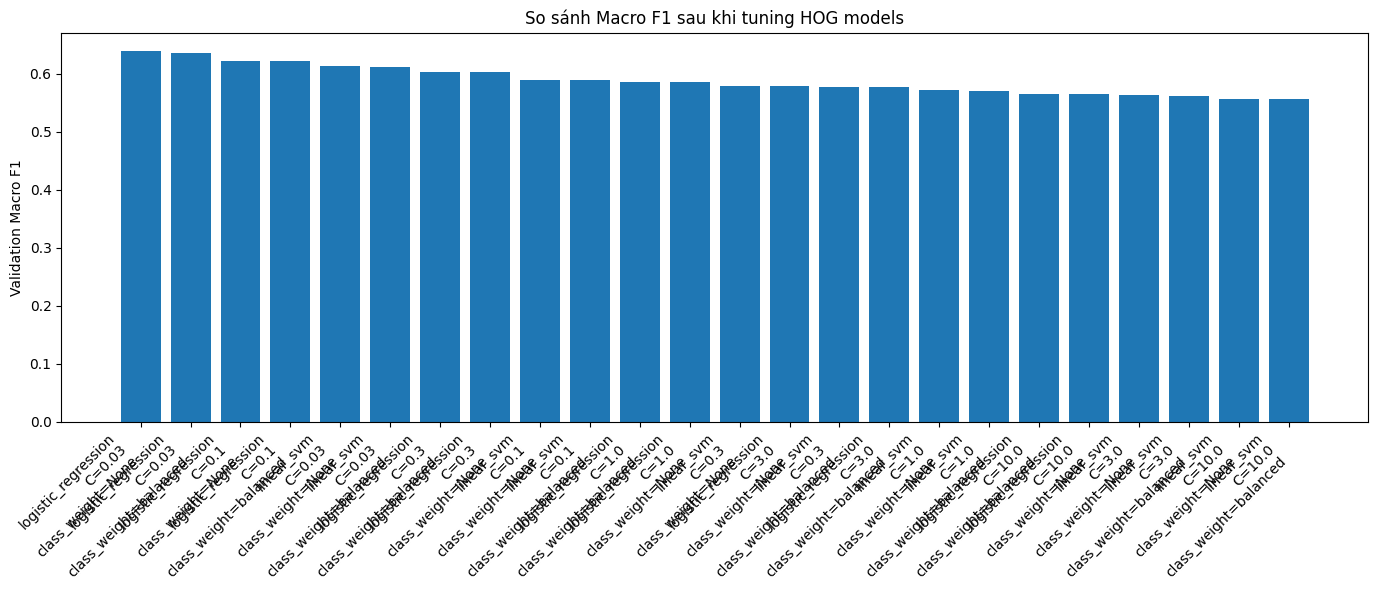

Đã lưu biểu đồ tuning tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/tuning_macro_f1_comparison_full.png


In [ ]:
plot_df = tuning_results_df.copy()
plot_df["config_name"] = (
    plot_df["model_type"]
    + "\nC=" + plot_df["C"].astype(str)
    + "\nclass_weight=" + plot_df["class_weight"].astype(str)
)

plt.figure(figsize=(14, 6))
plt.bar(plot_df["config_name"], plot_df["macro_f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Macro F1")
plt.title("So sánh Macro F1 sau khi tuning HOG models")
plt.tight_layout()

tuning_plot_path = FIGURES_DIR / f"tuning_macro_f1_comparison_{mode}.png"
plt.savefig(tuning_plot_path, dpi=150)
plt.show()

print("Đã lưu biểu đồ tuning tại:")
print(tuning_plot_path)


Đã xóa biểu đồ cũ: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/tuning_macro_f1_comparison_full.png


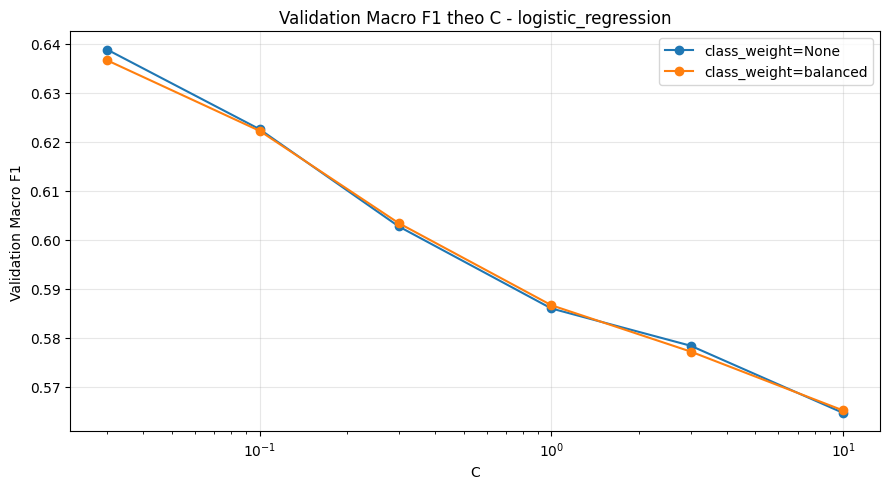

Đã lưu biểu đồ tuning cho logistic_regression tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/tuning_macro_f1_logistic_regression_full.png


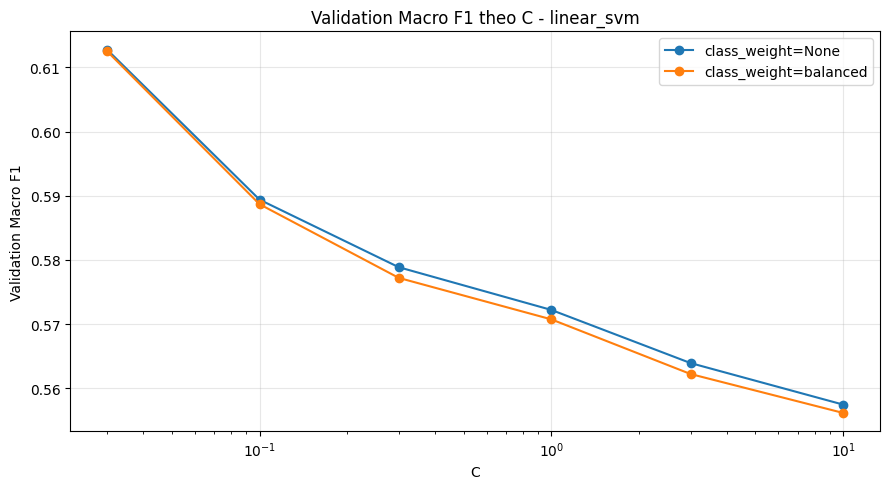

Đã lưu biểu đồ tuning cho linear_svm tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/tuning_macro_f1_linear_svm_full.png


{'logistic_regression': '/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/tuning_macro_f1_logistic_regression_full.png',
 'linear_svm': '/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/tuning_macro_f1_linear_svm_full.png'}

In [ ]:
# Vẽ biểu đồ đường riêng cho từng model
# Mỗi biểu đồ thể hiện Validation Macro F1 theo C
# Mỗi đường tương ứng với một giá trị class_weight

plot_df = tuning_results_df.copy()
plot_df["C"] = plot_df["C"].astype(float)

# Xóa biểu đồ cũ nếu đã từng tạo để tránh nhầm lẫn
old_combined_plot_path = FIGURES_DIR / f"tuning_macro_f1_comparison_{mode}.png"
if old_combined_plot_path.exists():
    old_combined_plot_path.unlink()
    print("Đã xóa biểu đồ cũ:", old_combined_plot_path)

line_plot_paths = {}

for model_type in plot_df["model_type"].unique():
    model_plot_df = plot_df[plot_df["model_type"] == model_type].copy()
    model_plot_df = model_plot_df.sort_values(by="C")

    plt.figure(figsize=(9, 5))

    for class_weight_value in model_plot_df["class_weight"].unique():
        sub_df = model_plot_df[
            model_plot_df["class_weight"] == class_weight_value
        ].copy()

        sub_df = sub_df.sort_values(by="C")

        plt.plot(
            sub_df["C"],
            sub_df["macro_f1"],
            marker="o",
            label=f"class_weight={class_weight_value}"
        )

    plt.xscale("log")
    plt.xlabel("C")
    plt.ylabel("Validation Macro F1")
    plt.title(f"Validation Macro F1 theo C - {model_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plot_path = FIGURES_DIR / f"tuning_macro_f1_{model_type}_{mode}.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()

    line_plot_paths[model_type] = str(plot_path)

    print(f"Đã lưu biểu đồ tuning cho {model_type} tại:")
    print(plot_path)

line_plot_paths

In [ ]:
# Xem cấu hình tốt nhất của từng loại model

best_each_model_df = (
    tuning_results_df
    .sort_values(by=["model_type", "macro_f1", "accuracy"], ascending=[True, False, False])
    .groupby("model_type")
    .head(1)
    .reset_index(drop=True)
)

display(best_each_model_df[[
    "model_type",
    "C",
    "class_weight",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "train_time_sec"
]])

,model_type,C,class_weight,accuracy,macro_f1,weighted_f1,train_time_sec
0,linear_svm,0.03,None,0.610556,0.612805,0.608943,133.355683
1,logistic_regression,0.03,None,0.634451,0.638829,0.634680,42.838442


## 15. So sánh best tuning với baseline cũ

Nếu file `cs114_baselines_metrics.csv` tồn tại, cell này sẽ lấy kết quả HOG baseline cũ để so sánh với kết quả sau tuning.


In [ ]:
baseline_metrics_path = METRICS_DIR / "cs114_baselines_metrics.csv"

comparison_rows = []

if baseline_metrics_path.exists():
    baseline_df = pd.read_csv(baseline_metrics_path)

    keep_baselines = baseline_df[
        baseline_df["experiment"].isin([
            "hog_logistic_regression",
            "hog_linear_svm"
        ])
    ].copy()

    for _, row in keep_baselines.iterrows():
        comparison_rows.append({
            "stage": "baseline",
            "experiment": row["experiment"],
            "model_type": row["experiment"].replace("hog_", ""),
            "macro_f1": row["macro_f1"],
            "accuracy": row["accuracy"],
            "params": "default"
        })
else:
    print("Không tìm thấy file baseline metrics:", baseline_metrics_path)


best_tuned_row = tuning_results_df.iloc[0]

comparison_rows.append({
    "stage": "best_tuned",
    "experiment": best_tuned_row["experiment"],
    "model_type": best_tuned_row["model_type"],
    "macro_f1": best_tuned_row["macro_f1"],
    "accuracy": best_tuned_row["accuracy"],
    "params": best_tuned_row["params"]
})

comparison_df = pd.DataFrame(comparison_rows)

comparison_path = METRICS_DIR / f"cs114_tuning_vs_baseline_{mode}.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Đã lưu bảng so sánh baseline/tuning tại:")
print(comparison_path)

display(comparison_df)


Đã lưu bảng so sánh baseline/tuning tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_tuning_vs_baseline_full.csv


,stage,experiment,model_type,macro_f1,accuracy,params
0,baseline,hog_logistic_regression,logistic_regression,0.586621,0.583809,default
1,baseline,hog_linear_svm,linear_svm,0.570721,0.568474,default
2,best_tuned,hog_logistic_regression,logistic_regression,0.638829,0.634451,"{""C"": 0.03, ""class_weight"": null, ""max_iter"": ..."


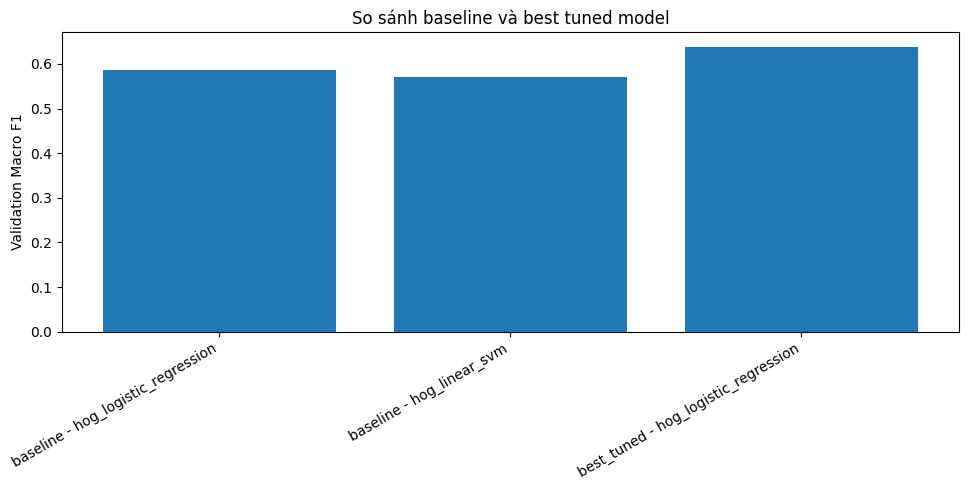

Đã lưu biểu đồ so sánh baseline/tuning tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/tuning_vs_baseline_macro_f1_full.png


In [ ]:
if len(comparison_df) > 0:
    plt.figure(figsize=(10, 5))
    labels = comparison_df["stage"] + " - " + comparison_df["experiment"]
    plt.bar(labels, comparison_df["macro_f1"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Validation Macro F1")
    plt.title("So sánh baseline và best tuned model")
    plt.tight_layout()

    comparison_plot_path = FIGURES_DIR / f"tuning_vs_baseline_macro_f1_{mode}.png"
    plt.savefig(comparison_plot_path, dpi=150)
    plt.show()

    print("Đã lưu biểu đồ so sánh baseline/tuning tại:")
    print(comparison_plot_path)


## 16. Chọn model tốt nhất sau tuning

Model tốt nhất được chọn theo:

```text
validation macro_f1 cao nhất
nếu bằng nhau thì xét tiếp validation accuracy
```


In [ ]:
best_tuned_row = tuning_results_df.iloc[0]

best_model_key = (
    f"{best_tuned_row['experiment']}__C={best_tuned_row['C']}__class_weight={best_tuned_row['class_weight']}"
)

best_tuned_model = trained_tuned_models[best_model_key]

print("Best tuned model key:", best_model_key)
print("Best tuned row:")
display(best_tuned_row.to_frame().T)

best_tuned_params = json.loads(best_tuned_row["params"])
print("Best tuned params:", best_tuned_params)


Best tuned model key: hog_logistic_regression__C=0.03__class_weight=None
Best tuned row:


,experiment,model_type,feature_type,mode,n_train,n_val,n_features,params,C,class_weight,max_iter,train_time_sec,val_predict_time_sec,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,hog_logistic_regression,logistic_regression,hog,full,11212,2804,1764,"{""C"": 0.03, ""class_weight"": null, ""max_iter"": ...",0.03,None,5000,42.838442,0.067849,0.634451,0.640173,0.638353,0.638829,0.635773,0.634451,0.63468


Best tuned params: {'C': 0.03, 'class_weight': None, 'max_iter': 5000}


## 17. In classification report của best tuned model trên validation set


In [ ]:
y_val_pred_best = best_tuned_model.predict(X_val)

print_classification_report(
    y_val,
    y_val_pred_best,
    title=f"Validation report - Best tuned model: {best_tuned_row['experiment']}"
)


Validation report - Best tuned model: hog_logistic_regression
              precision    recall  f1-score   support

   buildings       0.71      0.71      0.71       438
      forest       0.84      0.87      0.86       454
     glacier       0.47      0.47      0.47       481
    mountain       0.44      0.47      0.46       501
         sea       0.60      0.54      0.57       455
      street       0.77      0.76      0.77       475

    accuracy                           0.63      2804
   macro avg       0.64      0.64      0.64      2804
weighted avg       0.64      0.63      0.63      2804



## 18. Đánh giá model tốt nhất trên test set

Chỉ sau khi đã chọn xong model tốt nhất bằng validation set, ta mới đánh giá trên test set.


In [ ]:
start_time = time.time()
y_test_pred = best_tuned_model.predict(X_test)
test_predict_time = time.time() - start_time

test_metrics = compute_metrics(y_test, y_test_pred)

print("Test predict time:", round(test_predict_time, 2), "sec")
print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

print_classification_report(
    y_test,
    y_test_pred,
    title=f"Test report - Best tuned model: {best_tuned_row['experiment']}"
)


Test predict time: 0.11 sec
Test metrics:
accuracy: 0.6530
macro_precision: 0.6612
macro_recall: 0.6594
macro_f1: 0.6596
weighted_precision: 0.6545
weighted_recall: 0.6530
weighted_f1: 0.6530
Test report - Best tuned model: hog_logistic_regression
              precision    recall  f1-score   support

   buildings       0.74      0.70      0.72       437
      forest       0.83      0.89      0.86       474
     glacier       0.56      0.55      0.55       553
    mountain       0.48      0.53      0.50       525
         sea       0.59      0.55      0.57       510
      street       0.77      0.73      0.75       501

    accuracy                           0.65      3000
   macro avg       0.66      0.66      0.66      3000
weighted avg       0.65      0.65      0.65      3000



## 19. Lưu test metrics


In [ ]:
test_metrics_df = pd.DataFrame([{
    "experiment": best_tuned_row["experiment"],
    "model_type": best_tuned_row["model_type"],
    "feature_type": "hog",
    "mode": mode,
    "n_test": len(y_test),
    "n_features": X_test.shape[1],
    "test_predict_time_sec": test_predict_time,
    "best_validation_macro_f1": best_tuned_row["macro_f1"],
    "best_validation_accuracy": best_tuned_row["accuracy"],
    "params": best_tuned_row["params"],
    **test_metrics
}])

test_metrics_path = METRICS_DIR / f"cs114_best_tuned_model_test_metrics_{mode}.csv"
test_metrics_df.to_csv(test_metrics_path, index=False)

print("Đã lưu test metrics tại:")
print(test_metrics_path)

display(test_metrics_df)


Đã lưu test metrics tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_best_tuned_model_test_metrics_full.csv


,experiment,model_type,feature_type,mode,n_test,n_features,test_predict_time_sec,best_validation_macro_f1,best_validation_accuracy,params,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,hog_logistic_regression,logistic_regression,hog,full,3000,1764,0.106108,0.638829,0.634451,"{""C"": 0.03, ""class_weight"": null, ""max_iter"": ...",0.653,0.661154,0.65938,0.659553,0.654452,0.653,0.653022


## 20. Lưu prediction trên test set

File prediction này sẽ dùng cho bước `07_error_analysis.ipynb`.


In [ ]:
test_pred_df = used_test_df.copy()

test_pred_df["true_label_idx"] = y_test
test_pred_df["pred_label_idx"] = y_test_pred

test_pred_df["true_label"] = test_pred_df["true_label_idx"].map(idx_to_class)
test_pred_df["pred_label"] = test_pred_df["pred_label_idx"].map(idx_to_class)

test_pred_df["is_correct"] = (
    test_pred_df["true_label_idx"] == test_pred_df["pred_label_idx"]
)

important_cols = [
    "relative_path",
    "true_label",
    "pred_label",
    "true_label_idx",
    "pred_label_idx",
    "is_correct"
]

remaining_cols = [c for c in test_pred_df.columns if c not in important_cols]
test_pred_df = test_pred_df[important_cols + remaining_cols]

prediction_path = PREDICTIONS_DIR / f"cs114_best_tuned_model_test_predictions_{mode}.csv"
test_pred_df.to_csv(prediction_path, index=False)

print("Đã lưu best tuned model predictions tại:")
print(prediction_path)

display(test_pred_df.head())

print("Số dự đoán đúng:", test_pred_df["is_correct"].sum())
print("Tổng số ảnh test:", len(test_pred_df))
print("Accuracy kiểm tra lại:", test_pred_df["is_correct"].mean())


Đã lưu best tuned model predictions tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions/cs114_best_tuned_model_test_predictions_full.csv


,relative_path,true_label,pred_label,true_label_idx,pred_label_idx,is_correct,split,label,file_name,width,height,mode,error,file_hash,label_idx
0,seg_test/buildings/20057.jpg,buildings,buildings,0,0,True,test,buildings,20057.jpg,150,150,RGB,NaN,c05af5c7bcce817b4e03c89cf99523b3,0
1,seg_test/buildings/20060.jpg,buildings,street,0,5,False,test,buildings,20060.jpg,150,150,RGB,NaN,294b7b292e7ba7d938b7819cde55125c,0
2,seg_test/buildings/20061.jpg,buildings,buildings,0,0,True,test,buildings,20061.jpg,150,150,RGB,NaN,1dc62bcc7c181f63d546cef3a108ac0e,0
3,seg_test/buildings/20064.jpg,buildings,buildings,0,0,True,test,buildings,20064.jpg,150,150,RGB,NaN,b1369f91a642bda82a51b041f97870a9,0
4,seg_test/buildings/20073.jpg,buildings,glacier,0,2,False,test,buildings,20073.jpg,150,150,RGB,NaN,3c520c75fde0970f78531d6fbaa334bb,0


Số dự đoán đúng: 1959
Tổng số ảnh test: 3000
Accuracy kiểm tra lại: 0.653


## 21. Vẽ và lưu confusion matrix

Confusion matrix giúp biết model nhầm lớp nào với lớp nào.


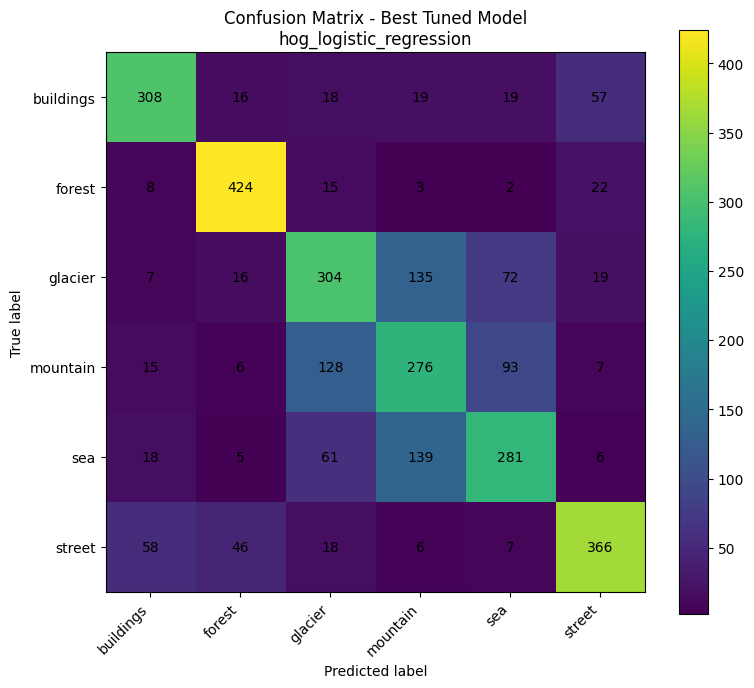

Đã lưu confusion matrix tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/confusion_matrix_best_tuned_model_full.png


In [ ]:
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=list(range(len(class_names)))
)

plt.figure(figsize=(8, 7))
plt.imshow(cm)

plt.title(f"Confusion Matrix - Best Tuned Model\n{best_tuned_row['experiment']}")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    ticks=np.arange(len(class_names)),
    labels=class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(class_names)),
    labels=class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

cm_path = FIGURES_DIR / f"confusion_matrix_best_tuned_model_{mode}.png"
plt.savefig(cm_path, dpi=150)
plt.show()

print("Đã lưu confusion matrix tại:")
print(cm_path)


## 22. Lưu best tuned model

File `.joblib` này chứa model tốt nhất sau tuning, mapping label, config và metrics.


In [ ]:
best_tuned_package = {
    "model": best_tuned_model,
    "experiment": best_tuned_row["experiment"],
    "model_type": best_tuned_row["model_type"],
    "feature_type": "hog",
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "class_names": class_names,
    "config": {
        "hog_size": HOG_SIZE,
        "fast_mode": FAST_MODE,
        "mode": mode,
        "seed": SEED,
        "selection_metric": "validation_macro_f1"
    },
    "best_params": best_tuned_params,
    "validation_metrics": best_tuned_row.to_dict(),
    "test_metrics": test_metrics
}

model_path = MODELS_DIR / f"best_tuned_model_{mode}.joblib"
joblib.dump(best_tuned_package, model_path)

print("Đã lưu best tuned model tại:")
print(model_path)


Đã lưu best tuned model tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/models/cs114/best_tuned_model_full.joblib


## 23. Lưu summary JSON

File này giúp xem nhanh kết quả cuối của notebook 04.


In [ ]:
summary = {
    "notebook": "04_cs114_tuning.ipynb",
    "mode": mode,
    "fast_mode": FAST_MODE,
    "best_experiment": best_tuned_row["experiment"],
    "best_model_type": best_tuned_row["model_type"],
    "feature_type": "hog",
    "best_params": best_tuned_params,
    "validation_macro_f1": float(best_tuned_row["macro_f1"]),
    "validation_accuracy": float(best_tuned_row["accuracy"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "test_accuracy": float(test_metrics["accuracy"]),
    "outputs": {
        "tuning_results": str(tuning_results_path),
        "comparison": str(comparison_path),
        "test_metrics": str(test_metrics_path),
        "predictions": str(prediction_path),
        "confusion_matrix": str(cm_path),
        "model": str(model_path)
    }
}

summary_path = METRICS_DIR / f"cs114_tuning_summary_{mode}.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=4)

print("Đã lưu summary tại:")
print(summary_path)

summary


Đã lưu summary tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_tuning_summary_full.json


{'notebook': '04_cs114_tuning.ipynb',
 'mode': 'full',
 'fast_mode': False,
 'best_experiment': 'hog_logistic_regression',
 'best_model_type': 'logistic_regression',
 'feature_type': 'hog',
 'best_params': {'C': 0.03, 'class_weight': None, 'max_iter': 5000},
 'validation_macro_f1': 0.6388288289833918,
 'validation_accuracy': 0.634450784593438,
 'test_macro_f1': 0.6595533500092478,
 'test_accuracy': 0.653,
 'outputs': {'tuning_results': '/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_tuning_results_full.csv',
  'comparison': '/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_tuning_vs_baseline_full.csv',
  'test_metrics': '/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_best_tuned_model_test_metrics_full.csv',
  'predictions': '/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_imag

## 24. Kết luận sau khi chạy notebook

Sau khi chạy xong notebook này, bạn cần ghi lại:

1. Model nào tốt nhất sau tuning.
2. Tham số tốt nhất là gì.
3. Validation Macro F1 sau tuning.
4. Test Accuracy và Test Macro F1.
5. So sánh với baseline cũ.
6. Các lớp nào còn bị nhầm nhiều trong confusion matrix.

Các file quan trọng được tạo:

```text
outputs/metrics/cs114_tuning_results_full.csv
outputs/metrics/cs114_tuning_vs_baseline_full.csv
outputs/metrics/cs114_best_tuned_model_test_metrics_full.csv
outputs/metrics/cs114_tuning_summary_full.json

outputs/predictions/cs114_best_tuned_model_test_predictions_full.csv

outputs/figures/cs114/tuning_macro_f1_comparison_full.png
outputs/figures/cs114/tuning_vs_baseline_macro_f1_full.png
outputs/figures/cs114/confusion_matrix_best_tuned_model_full.png

models/cs114/best_tuned_model_full.joblib
```

